In [3]:
from tensorflow.keras.datasets import mnist 

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [2]:
type(X_train)

numpy.ndarray

In [4]:
#픽셀값 정규화
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

# 합성곱 신경망 구조

In [ ]:
from tensorflow.keras import Sequential, layers
model = Sequential([
    layers.Input(shape=(28,28,1)), #3차원 이미지 1장의 입력
    
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),
    
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'), #분류 계층
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
  ])

model.summary()

I0000 00:00:1774596122.437282  196560 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.layers[0].get_weights()

[array([[[[-0.02784438, -0.12341648, -0.02024755,  0.13081582,
            0.00447224,  0.1030446 ,  0.05102065,  0.07444379,
           -0.13155743,  0.12275662, -0.04909666,  0.03644879,
           -0.06554117,  0.12930082, -0.13993362, -0.04423451,
            0.01843214,  0.06429537, -0.08776818,  0.09246159,
            0.08546032, -0.0732091 ,  0.12984444, -0.04564194,
           -0.03444916,  0.09256274,  0.09276952, -0.03912189,
           -0.02588627, -0.12848687, -0.11934675, -0.01045974]],
 
         [[-0.09290314,  0.09027022,  0.05054544, -0.04936766,
            0.10266039,  0.11000089, -0.09803849, -0.13362233,
            0.01879518, -0.1175148 ,  0.10050187, -0.04963937,
            0.05934027, -0.04495376, -0.08248609, -0.1015644 ,
            0.09102798, -0.00532512, -0.04964831,  0.01375012,
           -0.05041765, -0.12168301, -0.06661475, -0.08367188,
           -0.03227356,  0.09620041, -0.06408947,  0.1368684 ,
           -0.02734214, -0.06631383,  0.10054463, -

In [15]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


In [17]:
history = model.fit(X_train, y_train, batch_size=128, epochs=10,
                    validation_split=0.2, #추가
                    verbose=1)

Epoch 1/10


I0000 00:00:1774596455.978991  199856 service.cc:153] XLA service 0x77649c032620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774596455.979021  199856 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774596456.006807  199856 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774596456.154461  199856 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774596456.231061  199856 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1791__.33


  7/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.1563 - loss: 2.2490

I0000 00:00:1774596461.171813  199856 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8837 - loss: 0.3721 - val_accuracy: 0.9772 - val_loss: 0.0796
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9643 - loss: 0.1193 - val_accuracy: 0.9836 - val_loss: 0.0544
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9737 - loss: 0.0875 - val_accuracy: 0.9869 - val_loss: 0.0452
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9781 - loss: 0.0721 - val_accuracy: 0.9887 - val_loss: 0.0416
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9811 - loss: 0.0618 - val_accuracy: 0.9885 - val_loss: 0.0383
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9822 - loss: 0.0589 - val_accuracy: 0.9895 - val_loss: 0.0379
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9845 - loss: 0.0513 - val_accuracy: 0.9899 - val_loss: 0.0355
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9859 - loss: 0.0451 - val_accuracy: 0.9909 - va

In [20]:
loss, acc = model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9917 - loss: 0.0239


In [21]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    # 그래프 크기 설정 및 서브플롯 생성
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Loss (손실) 시각화
    ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
    if 'val_loss' in history.history:
        ax[0].plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
    ax[0].set_title('Model Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)

    # 2. Accuracy (정확도) 시각화
    ax[1].plot(history.history['accuracy'], label='Train Accuracy', color='green')
    if 'val_accuracy' in history.history:
        ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
    ax[1].set_title('Model Accuracy')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

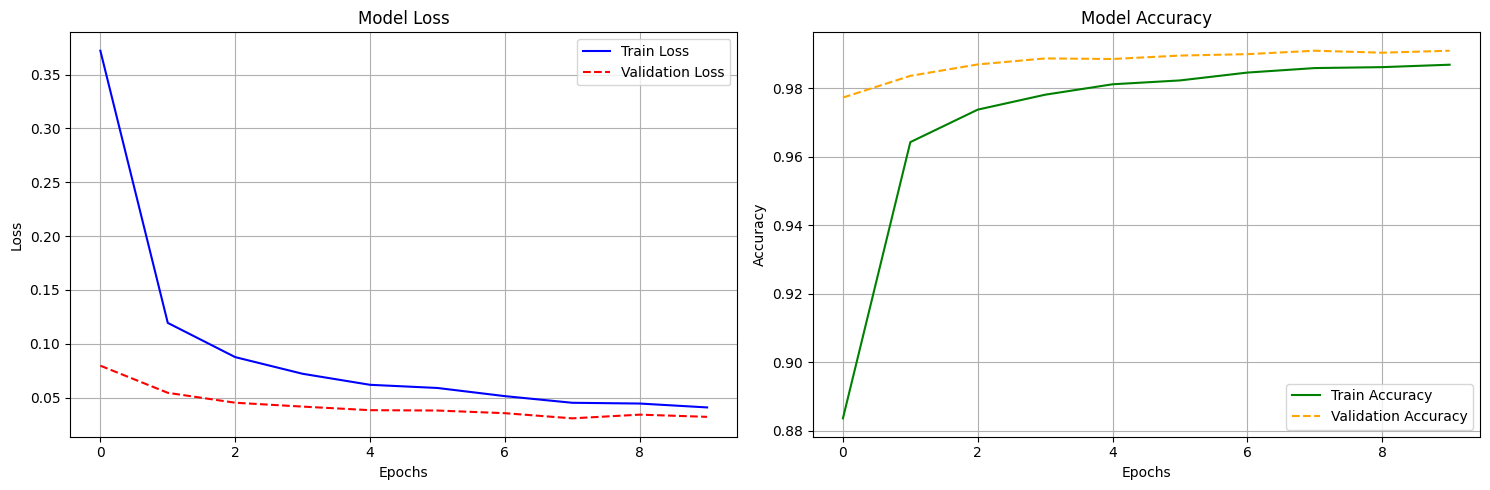

In [22]:
plot_learning_curves(history)

/tmp/ipykernel_196560/1774303896.py:29: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_196560/1774303896.py:29: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_196560/1774303896.py:29: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_196560/1774303896.py:29: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_196560/1774303896.py:29: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_196560/1774303896.py:29: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_196560/1774303896.py:29: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu San

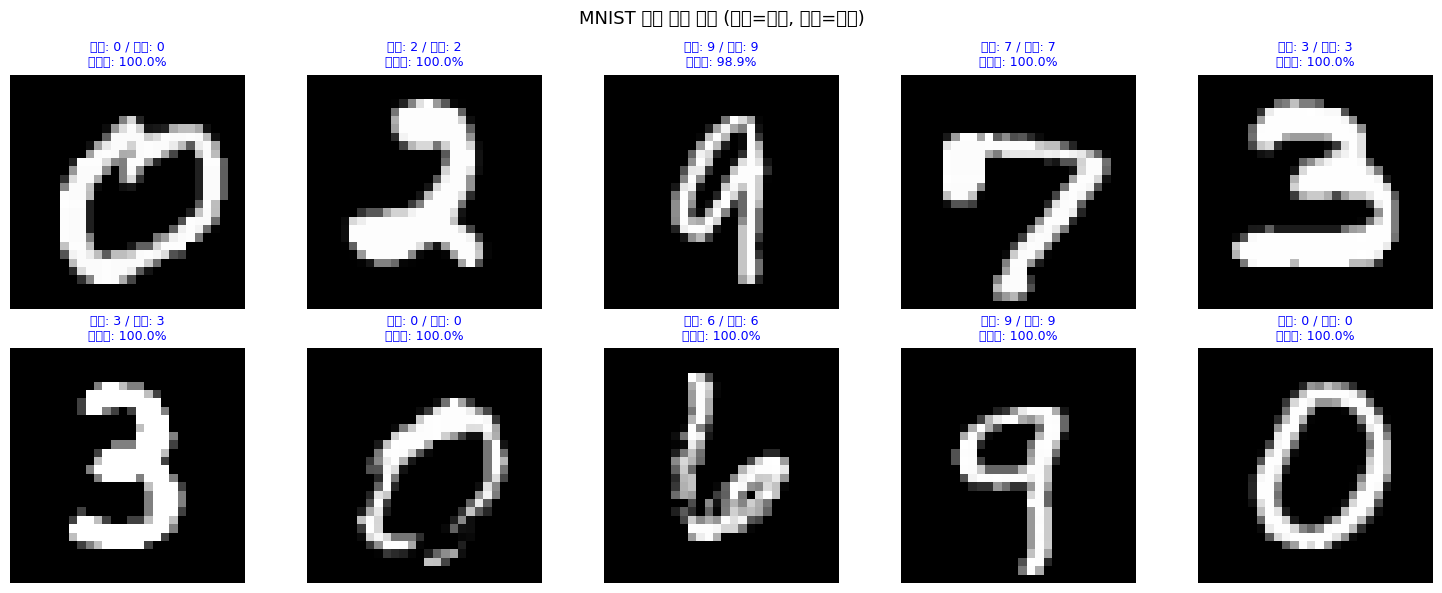

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 테스트 이미지 10개 랜덤 선택
indices = np.random.randint(0, len(X_test), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = y_test[idx]

# 예측
    pred_prob = model.predict(img.reshape(1, 28, 28, 1), verbose=0)
    pred_label = np.argmax(pred_prob)
    confidence = pred_prob[0][pred_label] * 100

# 시각화
    axes[i].imshow(img.reshape(28, 28), cmap='gray')
    axes[i].set_title(
        f'정답: {true_label} / 예측: {pred_label}\n확신도: {confidence:.1f}%',
        color='blue' if true_label == pred_label else 'red',
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('MNIST 실제 예측 결과 (파랑=정답, 빨강=오답)', fontsize=13)
plt.tight_layout()
plt.show()

# RESNET 추론 테스트

In [1]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [12]:
# resnet_model = ResNet50(input_shape=(224,224,3),
# include_top=False, weights='imagenet')
resnet_model = ResNet50(weights='imagenet')
# resnet_model.summary()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


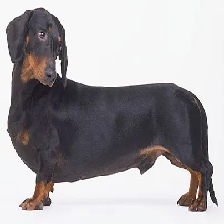

In [17]:
from tensorflow.keras.preprocessing import image
rab_img = image.load_img('dachshund.jpg', target_size= (224,224))
rab_img

In [18]:
type(rab_img)

PIL.Image.Image

In [9]:
import numpy as np

In [19]:
X = np.expand_dims(image.img_to_array(rab_img), axis=0)
X.shape

(1, 224, 224, 3)

In [20]:
# 추론
pred = resnet_model.predict(X)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


array([[3.11893344e-10, 2.05138906e-10, 5.53280588e-10, 1.18529631e-09,
        1.08986531e-09, 2.73280900e-08, 4.13093809e-10, 7.37893213e-09,
        8.95398689e-09, 9.50733034e-11, 5.66431207e-11, 2.98614562e-12,
        2.19430960e-10, 3.25609921e-11, 8.23432919e-11, 7.77157991e-11,
        6.98882729e-10, 4.15159551e-09, 3.88421184e-10, 2.20452046e-10,
        1.15209307e-10, 1.26458372e-10, 1.93589172e-10, 1.85636878e-07,
        2.45396126e-09, 3.45693058e-10, 1.25971189e-09, 1.11590870e-09,
        4.01185574e-09, 1.09900790e-10, 8.20344313e-12, 2.22900962e-10,
        7.80969789e-10, 2.45109238e-10, 1.89717841e-09, 1.01326295e-10,
        2.83741319e-09, 6.09147566e-10, 9.45657419e-09, 5.27910826e-10,
        5.33464717e-10, 7.61603669e-10, 2.67470188e-08, 2.20339604e-08,
        2.39280307e-09, 1.69428704e-09, 7.69761130e-11, 3.22616933e-09,
        6.09524431e-09, 1.65246341e-11, 1.10003548e-10, 2.61580055e-07,
        2.02104555e-10, 2.69778061e-10, 3.18955348e-11, 3.874318

In [21]:
from tensorflow.keras.applications.resnet50 import decode_predictions

decode_predictions(pred, top=3)

[[('n02088466', 'bloodhound', np.float32(0.43700063)),
  ('n02090379', 'redbone', np.float32(0.41398308)),
  ('n02089078', 'black-and-tan_coonhound', np.float32(0.09503639))]]

In [ ]:
# 전이학습 

In [22]:
resnet_model_tl = ResNet50(input_shape=(224,224,3), include_top=False, weights='imagenet')

In [ ]:
resnet_model_tl.trainable = True

#전이학습모델 
model = Sequential()
model.add(resnet_model_tl)
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │   102,761,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,352,259 (482.00 MB)

 Trainable params: 126,299,139 (481.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [24]:
import zipfile
zip_file_path = 'glaucoma.zip' #압축 파일 경로

with zipfile.ZipFile(zip_file_path, 'r') as f: 
  f.extractall('.datasets/')

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
  rotation_range=20,
  width_shift_range=0.2, height_shift_range=0.2,
  horizontal_flip=True
)
train_gen_data = train_gen.flow_from_directory('.datasets/glaucoma/train', target_size=(224,224),batch_size=32, class_mode='sparse')

Found 1394 images belonging to 3 classes.


In [29]:
test_gen = ImageDataGenerator()
test_data = test_gen.flow_from_directory('.datasets/glaucoma/test', target_size=(224,224),batch_size=32, class_mode='sparse')

Found 150 images belonging to 3 classes.


In [30]:
train_gen_data.image_shape, test_data.image_shape

((224, 224, 3), (224, 224, 3))

In [31]:
# 모델 설정 
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

In [33]:
# 모델 전이학습
model.fit(
  train_gen_data, validation_data = test_data, epochs=20, verbose=1
)

Epoch 1/20


I0000 00:00:1774840417.240470    3079 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1774840441.289490    5481 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_58812__.391


 5/44 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - accuracy: 0.4326 - loss: 62.6255

I0000 00:00:1774840468.193513    5479 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_58812__.391


44/44 ━━━━━━━━━━━━━━━━━━━━ 86s 900ms/step - accuracy: 0.6420 - loss: 10.1079 - val_accuracy: 0.5533 - val_loss: 6706.3315
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 224ms/step - accuracy: 0.6915 - loss: 0.7281 - val_accuracy: 0.3867 - val_loss: 10.8018
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 202ms/step - accuracy: 0.7095 - loss: 0.6427 - val_accuracy: 0.6267 - val_loss: 1.4161
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 205ms/step - accuracy: 0.7532 - loss: 0.5841 - val_accuracy: 0.5933 - val_loss: 0.9248
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 223ms/step - accuracy: 0.7475 - loss: 0.5965 - val_accuracy: 0.6867 - val_loss: 0.6780
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 217ms/step - accuracy: 0.7482 - loss: 0.5644 - val_accuracy: 0.6667 - val_loss: 0.9899
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 201ms/step - accuracy: 0.7669 - loss: 0.5359 - val_accuracy: 0.6467 - val_loss: 0.8672
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - accuracy: 0.7812 - loss: 0.5034 - val_accuracy: 0.56

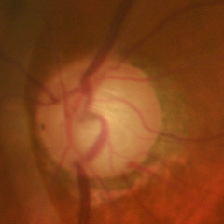

In [34]:
from tensorflow.keras.preprocessing import image
grau_img = image.load_img('test.png', target_size= (224,224))
grau_img

In [35]:
X = np.expand_dims(image.img_to_array(grau_img), axis=0)

In [36]:
pred = model.predict(X, verbose=0)
pred

array([[7.964980e-42, 1.751545e-28, 1.000000e+00]], dtype=float32)